# Pauli-based computation, end to end

This notebook runs the pipeline from the *Pauli-Based Computation* slides on a real example: the 4-qubit circuit of Litinski, "A Game of Surface Codes" ([arXiv:1808.02892](https://arxiv.org/abs/1808.02892)), Fig. 4.

| Pipeline stage (slide 2) | Where | How it is done here |
|---|---|---|
| Logical circuit → Clifford + T | not covered | the example is already Clifford + T |
| **1.** Clifford + T → magic states + multi-qubit Pauli measurements | sections 1 to 5 | exact, checked against a statevector |
| **2.** → factory + compute code patches | sections 6 and 7 | **factory:** `[[6,2,2]]` H6 distillation ([arXiv:2506.14688](https://arxiv.org/abs/2506.14688)), built by LightStim and simulated at the physical level with Clifft. **Compute block:** ideal logical qubits, not surface code patches (see the last section) |

| Section | Slide | Result shown |
|---|---|---|
| 1. Gates as Pauli product rotations | 4 | H, S, T and CNOT equal their rotation forms |
| 2. Commute or anticommute | 5 | the counting test, checked on 2000 random pairs |
| 3. Commute the Cliffords out | 6 | 21 gates become 4 rotations and 4 measurements, same output distribution |
| 4. T layers | 7 | Fig. 6 goes from 4 layers to 2; Fig. 4 is 1 layer |
| 5. A π/8 rotation consumes a magic state | 8 | the executed schedule is measurements only, and reproduces the circuit |
| 6. The factory: H6 distillation | 11 | the block accepts correct inputs and rejects wrong ones |
| 7. Results with noisy T gates | 11 | distilled states turn a first-order error into a second-order one |

Everything runs in a few minutes.

In [1]:
import clifft
import matplotlib.pyplot as plt
import numpy as np
import stim

from ppqc import (BareMagic, H6Magic, build_branch_circuit, circuit_distribution, cnot, compile_to_ppm,
                  h, litinski_fig4, ppm_distribution, run, s, t, t_layers, total_variation)
from ppqc.compiler import PI_8, PPMProgram, Rotation
from ppqc.magic import Emitter

SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

def new_axes(width=7.0, height=3.8, ncols=1):
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), facecolor=SURFACE)
    for ax in np.atleast_1d(axes):
        ax.set_facecolor(SURFACE)
        ax.grid(True, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(GRID)
        ax.tick_params(colors=MUTED, length=0)
    return fig, axes

def line(ax, x, y, color, label, yerr=None):
    if yerr is not None:
        ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor=color, elinewidth=1.2, capsize=2.5)
    ax.plot(x, y, color=color, linewidth=2, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=label)

def guide(ax, x, anchor, power, label):
    # Dashed reference line through (x[0], anchor) with slope `power` on log-log axes.
    x = np.asarray(x, dtype=float)
    ax.plot(x, anchor * (x / x[0]) ** power, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    ax.annotate(label, (x[-1], anchor * (x[-1] / x[0]) ** power), xytext=(4, 0),
                textcoords="offset points", color=MUTED, fontsize=8, va="center")

def P(text):
    return stim.PauliString(text)

## 1. Gates as Pauli product rotations (slide 4)

A Pauli product is a tensor product of single-qubit Paulis, one per qubit, each of them I, X, Y or Z. Every gate is a rotation $P_\varphi = e^{-i\varphi P}$ about a Pauli product $P$:

| Angle | Kind | Examples |
|---|---|---|
| π/8 | non-Clifford | T is $Z_{\pi/8}$ |
| π/4 | Clifford | S is $Z_{\pi/4}$; H is $Z_{\pi/4} X_{\pi/4} Z_{\pi/4}$; CNOT is $(Z\otimes X)_{\pi/4}\, Z_{-\pi/4}\, X_{-\pi/4}$ |
| π/2 | Pauli | |

The cell below builds each gate from its rotations and compares it with the gate's matrix. A global phase is ignored. A minus sign on the Pauli means a negative angle.

In [2]:
def unitary(rotations, n):
    u = np.eye(2 ** n, dtype=complex)
    for r in rotations:
        angle = float(r.angle) * np.pi
        u = (np.cos(angle) * np.eye(2 ** n) - 1j * np.sin(angle) * r.pauli.to_unitary_matrix(endian="little")) @ u
    return u

def same_up_to_phase(a, b):
    return bool(np.isclose(abs(np.trace(a.conj().T @ b)), len(a)))

def named(gate):
    return stim.Tableau.from_named_gate(gate).to_unitary_matrix(endian="little")

gates = {
    "H": (h(0, 1), named("H"), 1),
    "S": (s(0, 1), named("S"), 1),
    "T": (t(0, 1), np.diag([1, np.exp(1j * np.pi / 4)]), 1),
    "CNOT": (cnot(0, 1, 2), named("CNOT"), 2),
}
print(f"{'gate':<6}{'as Pauli product rotations':<44}equals the gate")
for name, (rotations, matrix, n) in gates.items():
    text = "  ".join(f"({r.pauli})pi/{r.angle.denominator}" for r in rotations)
    print(f"{name:<6}{text:<44}{same_up_to_phase(unitary(rotations, n), matrix)}")

gate  as Pauli product rotations                  equals the gate
H     (+Z)pi/4  (+X)pi/4  (+Z)pi/4                True
S     (+Z)pi/4                                    True
T     (+Z)pi/8                                    True
CNOT  (+ZX)pi/4  (-Z_)pi/4  (-_X)pi/4             True


`litinski_fig4()` is the circuit at the top left of the paper's Fig. 4 (slide 6), written in this form. Qubits start in $|0\rangle$ and are measured in Z. In a string like `+XZ__` the four positions are q1 to q4.

In [3]:
N = 4
circuit = litinski_fig4()
for op in circuit:
    kind = {8: "pi/8  (T-type)", 4: "pi/4  (Clifford)", 2: "pi/2  (Pauli)"}[op.angle.denominator]
    print(f"{str(op.pauli):>6}   {kind}")
print(f"\n{len(circuit)} rotations, {sum(op.angle == PI_8 for op in circuit)} of them pi/8")

 +Z___   pi/8  (T-type)
 +_XZ_   pi/4  (Clifford)
 -_X__   pi/4  (Clifford)
 -__Z_   pi/4  (Clifford)
 -___X   pi/4  (Clifford)
 +XZ__   pi/4  (Clifford)
 -X___   pi/4  (Clifford)
 -_Z__   pi/4  (Clifford)
 +__X_   pi/4  (Clifford)
 +___Z   pi/8  (T-type)
 +X__Z   pi/4  (Clifford)
 -X___   pi/4  (Clifford)
 -___Z   pi/4  (Clifford)
 +Z___   pi/8  (T-type)
 +_Z__   pi/4  (Clifford)
 +__Z_   pi/8  (T-type)
 +___Z   pi/4  (Clifford)
 -X___   pi/4  (Clifford)
 +_X__   pi/4  (Clifford)
 +__X_   pi/4  (Clifford)
 +___X   pi/4  (Clifford)

21 rotations, 4 of them pi/8


## 2. Pauli products either commute or anticommute (slide 5)

Any two Pauli products satisfy $PP' = P'P$ or $PP' = -P'P$. The test: count the qubits where both have a non-identity Pauli and the two Paulis differ. An even count means they commute, an odd count means they anticommute.

In [4]:
def differing_positions(p, q):
    # Qubits where both have a non-identity Pauli and the Paulis differ.
    return sum(1 for k in range(len(p)) if p[k] and q[k] and p[k] != q[k])

for a, b in [("ZZ", "XX"), ("Z_", "XX"), ("YZZY", "Z___"), ("_XY_", "ZZZY")]:
    count = differing_positions(P(a), P(b))
    print(f"{a:>5} and {b:<5}: {count} position{'s' if count != 1 else ' '} -> {'commute' if count % 2 == 0 else 'anticommute'}")

rng_pairs = [(stim.PauliString.random(6), stim.PauliString.random(6)) for _ in range(2000)]
agree = sum((differing_positions(p, q) % 2 == 0) == p.commutes(q) for p, q in rng_pairs)
print(f"\ncounting test agrees with the operator algebra on {agree} of {len(rng_pairs)} random 6-qubit pairs")
print(f"if they anticommute, iPP' is again a Pauli product:  i * X * Z = {1j * P('X') * P('Z')}")

   ZZ and XX   : 2 positions -> commute
   Z_ and XX   : 1 position  -> anticommute
 YZZY and Z___ : 1 position  -> anticommute
 _XY_ and ZZZY : 2 positions -> commute

counting test agrees with the operator algebra on 2000 of 2000 random 6-qubit pairs
if they anticommute, iPP' is again a Pauli product:  i * X * Z = +Y


## 3. Commute the Cliffords out (slide 6)

Move each π/4 rotation $P_{\pi/4}$ to the right, past a later rotation or measurement about $P'$:

- if $P$ and $P'$ commute, nothing changes;
- if they anticommute, $P'$ becomes $iPP'$.

This is rule (a/b) of Fig. 4. Here it is applied to the third T gate of the circuit, which starts as $Z$ on q1. Each line is one Clifford that anticommutes with it on the way.

In [5]:
t_positions = [k for k, op in enumerate(circuit) if op.angle == PI_8]
index = t_positions[2]
p = circuit[index].pauli
print(f"T gate in the circuit:              {p}")
for clifford in reversed([op for op in circuit[:index] if op.angle != PI_8]):
    if not clifford.pauli.commutes(p):
        p = 1j * clifford.pauli * p
        print(f"  past ({clifford.pauli})pi/4, anticommutes  ->  {p}")
print(f"pi/8 rotation after all Cliffords:  {p}")

T gate in the circuit:              +Z___
  past (-X___)pi/4, anticommutes  ->  -Y___
  past (+X__Z)pi/4, anticommutes  ->  +Z__Z
  past (-X___)pi/4, anticommutes  ->  -Y__Z
  past (+XZ__)pi/4, anticommutes  ->  +ZZ_Z
  past (-___X)pi/4, anticommutes  ->  -ZZ_Y
  past (-_X__)pi/4, anticommutes  ->  +ZY_Y
  past (+_XZ_)pi/4, anticommutes  ->  -ZZZY
pi/8 rotation after all Cliffords:  -ZZZY


Doing this for every T gate leaves the Cliffords at the end of the circuit. Rule (c) then absorbs them into the final measurements the same way. `compile_to_ppm` does both steps.

The three stages below are the three circuits drawn on slide 6. Each one is checked against the original with an exact statevector.

In [6]:
program = compile_to_ppm(circuit, N)
ideal = circuit_distribution(circuit, N)

cliffords = [op for op in circuit if op.angle != PI_8]
after_ab = [Rotation(p, PI_8) for p in program.rotations] + cliffords  # T-type first, Cliffords last

Z_BASIS = "+Z___   +_Z__   +__Z_   +___Z"
stages = [
    ("original circuit", "interleaved", len(cliffords), Z_BASIS, 0.0),
    ("after rules (a/b)", "all first", len(cliffords), Z_BASIS,
     total_variation(ideal, circuit_distribution(after_ab, N))),
    ("after rule (c)", "all first", 0, "   ".join(str(m) for m in program.measurements),
     total_variation(ideal, ppm_distribution(program))),
]
print(f"{'stage':<19}{'pi/8 rotations':<16}{'Cliffords':<11}{'measurements':<34}distance from original")
for name, where, n_cliffords, measurements, distance in stages:
    print(f"{name:<19}{f'4, {where}':<16}{n_cliffords:<11}{measurements:<34}{distance:.1e}")

print("\npi/8 rotations:  " + "   ".join(str(p) for p in program.rotations))
print("measurements:    " + "   ".join(str(p) for p in program.measurements) + "    (replacing Z on q1..q4)")
print(f"\noperations: {len(circuit)} rotations + {N} measurements  ->  "
      f"{len(program.rotations)} rotations + {len(program.measurements)} measurements")

stage              pi/8 rotations  Cliffords  measurements                      distance from original
original circuit   4, interleaved  17         +Z___   +_Z__   +__Z_   +___Z     0.0e+00
after rules (a/b)  4, all first    17         +Z___   +_Z__   +__Z_   +___Z     1.1e-16
after rule (c)     4, all first    0          +YZZY   +XX__   -__Z_   +X__X     1.9e-16

pi/8 rotations:  +Z___   -___Y   -ZZZY   +_XY_
measurements:    +YZZY   +XX__   -__Z_   +X__X    (replacing Z on q1..q4)

operations: 21 rotations + 4 measurements  ->  4 rotations + 4 measurements


This is the bottom-right circuit of Fig. 4: the same four π/8 rotations and the same four measurements. The 17 Clifford gates are gone and the output distribution is unchanged to machine precision.

## 4. T layers (slide 7, optional)

π/8 rotations that commute with each other can be done in the same layer. The number of layers is the T depth. `t_layers` is the greedy algorithm of Fig. 6: move each rotation into the earliest layer it can reach. Below it runs on the six rotations drawn in Fig. 6, then on the Fig. 4 program.

In [7]:
def layers_in_order(rotations):
    # No reordering: start a new layer whenever a rotation does not commute with the current one.
    layers = []
    for p in rotations:
        if layers and all(p.commutes(q) for q in layers[-1]):
            layers[-1].append(p)
        else:
            layers.append([p])
    return layers

def show_layers(title, layers):
    print(f"{title}: {len(layers)} layer{'s' if len(layers) != 1 else ''}")
    for k, layer in enumerate(layers, 1):
        print(f"  layer {k}:  " + "   ".join(str(p) for p in layer))

fig6 = [-P("_Z__"), P("XYZY"), P("X_YZ"), -P("XZ_X"), P("XZY_"), P("Y_YY")]
show_layers("Fig. 6, in the order given", layers_in_order(fig6))
show_layers("Fig. 6, greedy", t_layers(fig6))
print()
show_layers("Fig. 4 program", t_layers(program.rotations))

Fig. 6, in the order given: 4 layers
  layer 1:  -_Z__
  layer 2:  +XYZY   +X_YZ
  layer 3:  -XZ_X   +XZY_
  layer 4:  +Y_YY
Fig. 6, greedy: 2 layers
  layer 1:  -_Z__   +X_YZ   +XZY_
  layer 2:  +XYZY   -XZ_X   +Y_YY

Fig. 4 program: 1 layer
  layer 1:  +Z___   -___Y   -ZZZY   +_XY_


The greedy pass reproduces Fig. 6: layers {1, 3, 5} and {2, 4, 6}. The four rotations of the Fig. 4 program all commute, so it has T depth 1.

## 5. A π/8 rotation is two measurements and a magic state (slide 8)

Surface codes cannot do a π/8 rotation directly. To rotate by π/8 about $P$, take a magic state $|m\rangle = |0\rangle + e^{i\pi/4}|1\rangle$ and (Fig. 7):

1. measure $P \otimes Z$ on the data and the magic state, giving outcome $m$;
2. measure $X$ on the magic state, giving outcome $x$;
3. if $m = 1$, a Clifford correction $P_{\pi/4}$ is owed; if $x = 1$, a Pauli correction $P_{\pi/2}$ is owed.

Neither correction is applied as a gate. A Pauli correction only flips the sign of later outcomes. A Clifford correction is commuted forward by the rule from section 3, so it changes *which* Pauli products are measured next.

The smallest example is one qubit, one rotation about X, then a Z measurement. Here are the circuits for $m = 0$ and $m = 1$. Qubit 0 is the data, qubit 1 the magic state.

In [8]:
one_rotation = PPMProgram(1, [P("X")], [P("Z")])
for m in (0, 1):
    text, expected, flips = build_branch_circuit(one_rotation, (m,), BareMagic(1))
    print(f"--- branch m = {m}: keep shots where the DETECTOR reads {expected[0]} ---\n{text}\n")

--- branch m = 0: keep shots where the DETECTOR reads 0 ---
R 0
RX 1
T 1
MPP X0*Z1
MX 1
MPP Z0
DETECTOR rec[-3]
OBSERVABLE_INCLUDE(0) rec[-2] rec[-1]

--- branch m = 1: keep shots where the DETECTOR reads 1 ---
R 0
RX 1
T 1
MPP X0*Z1
MX 1
MPP Y0
DETECTOR rec[-3]
OBSERVABLE_INCLUDE(0) rec[-2] rec[-1]



In the $m = 1$ branch the final measurement is `Y0`, not `Z0`: that is the Clifford correction $X_{\pi/4}$ absorbed into the measurement. The `DETECTOR` is $m$, and the `OBSERVABLE_INCLUDE` is the final outcome with the Pauli correction $x$ folded in.

### The Fig. 4 program as a measurement schedule

This is the output of stage 1 of the pipeline: magic states and multi-qubit Pauli measurements. Each row is one measurement; the fifth position is the magic state. Two outcome patterns are shown, to see the schedule adapt.

In [9]:
def schedule(program, branch):
    n = program.num_qubits
    text, _, _ = build_branch_circuit(program, branch, BareMagic(n))
    rows = []
    for row in text.splitlines():
        if row.startswith("MPP"):
            pauli = ["_"] * (n + 1)
            for term in row.split()[1].split("*"):
                pauli[int(term[1:])] = term[0]
            rows.append("".join(pauli[:n]) + " " + pauli[n])
        elif row.startswith("MX"):
            rows.append("_" * n + " X")
    return rows, sorted({row.split("(")[0].split()[0] for row in text.splitlines()})

first, instructions = schedule(program, (0, 0, 0, 0))
second, _ = schedule(program, (1, 0, 0, 0))
steps = [f"rotation {k + 1}: {what}" for k in range(4) for what in ("P x Z,  outcome m", "X on magic state")]
steps += [f"output q{k + 1}" for k in range(4)]
print(f"{'':<30}{'all m = 0':<12}{'m1 = 1':<12}")
for step, a, b in zip(steps, first, second):
    print(f"{step:<30}{a:<12}{b:<12}{'<- changed' if a != b else ''}")
print(f"\ninstructions in the circuit: {', '.join(instructions)}")
print("the only gate is the T that prepares each magic state; everything on the data is a measurement")

                              all m = 0   m1 = 1      
rotation 1: P x Z,  outcome m Z___ Z      Z___ Z      
rotation 1: X on magic state  ____ X      ____ X      
rotation 2: P x Z,  outcome m ___Y Z      ___Y Z      
rotation 2: X on magic state  ____ X      ____ X      
rotation 3: P x Z,  outcome m ZZZY Z      ZZZY Z      
rotation 3: X on magic state  ____ X      ____ X      
rotation 4: P x Z,  outcome m _XY_ Z      _XY_ Z      
rotation 4: X on magic state  ____ X      ____ X      
output q1                     YZZY _      XZZY _      <- changed
output q2                     XX__ _      YX__ _      <- changed
output q3                     __Z_ _      __Z_ _      
output q4                     X__X _      Y__X _      <- changed

instructions in the circuit: DETECTOR, MPP, MX, OBSERVABLE_INCLUDE, R, RX, T
the only gate is the T that prepares each magic state; everything on the data is a measurement


With $m_1 = 1$ the correction $(Z_{q1})_{\pi/4}$ is owed. It commutes with the other three rotations and anticommutes with three of the four output measurements, which change.

Clifft compiles a circuit once and cannot change a measurement basis mid-shot. So every pattern of $m$ outcomes is compiled as its own circuit and post-selected on that pattern. The accepted shots of all $2^t$ branches together are exactly the shots of the adaptive protocol. `run` does this.

### Result: the measurement schedule reproduces the circuit

The Fig. 4 program, run as measurements with perfect magic states, against the exact distribution of the original 21-gate circuit.

total variation distance from ideal: 0.0018


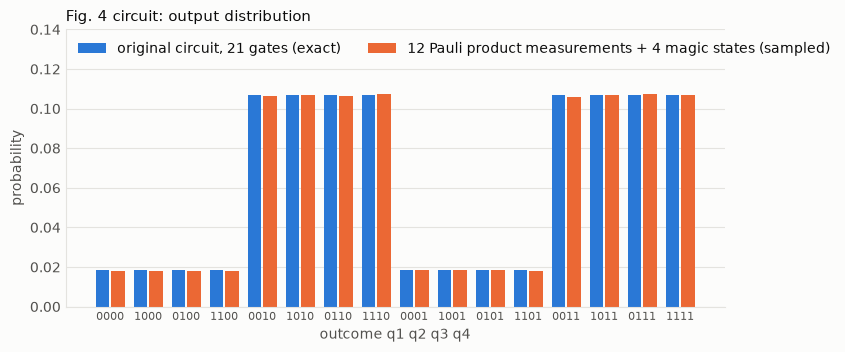

In [10]:
SHOTS = 500_000  # per branch; there are 2**4 = 16 branches

noiseless = run(program, lambda: BareMagic(N), SHOTS)
print(f"total variation distance from ideal: {total_variation(noiseless.distribution, ideal):.4f}")

labels = [format(i, "04b")[::-1] for i in range(16)]  # outcome of q1 q2 q3 q4
fig, ax = new_axes(8.5, 3.6)
x = np.arange(16)
ax.bar(x - 0.2, ideal, 0.36, color=BLUE, label="original circuit, 21 gates (exact)")
ax.bar(x + 0.2, noiseless.distribution, 0.36, color=ORANGE, label="12 Pauli product measurements + 4 magic states (sampled)")
ax.set_xticks(x, labels, fontsize=8)
ax.set_xlabel("outcome q1 q2 q3 q4", color=MUTED)
ax.set_ylabel("probability", color=MUTED)
ax.set_title("Fig. 4 circuit: output distribution", color=INK, loc="left", fontsize=11)
ax.set_ylim(0, 0.14)
ax.legend(frameon=False, labelcolor=INK, loc="upper left", ncols=2)
ax.grid(axis="x", visible=False)
plt.show()

## 6. The factory: magic states from H6 distillation (slide 11)

Stage 2 of the pipeline places the computation on code patches: a compute block that holds the data, and a factory that supplies magic states. This notebook simulates the factory.

The `[[6,2,2]]` H6 code holds two logical qubits. The protocol encodes two physical $|H+\rangle$ states into it, then checks that the encoded pair is still an eigenstate of logical $H \otimes H$. Any single fault is detected, and the run is discarded.

LightStim builds the protocol as a **Clifford proxy**, because Stim cannot hold a magic state: $|+\rangle$ stands in for $|H+\rangle$ and CX for controlled-H.

In [11]:
from lightstim.protocols.h6_distillation import build_h6_distillation_circuit

proxy, info, _ = build_h6_distillation_circuit(rounds=1, variant="e")
print(info, "\n")
print("\n".join(l for l in str(proxy).splitlines() if not l.startswith(("QUBIT_COORDS", "TICK", "SHIFT"))))

{'num_qubits': 12, 'num_detectors': 8, 'num_observables': 2, 'rounds': 1, 'variant': 'e', 'prep': 'fig1d'} 

RX 0 1 2 4
R 3 5
CX 2 3 4 5
CX 2 0 3 1
CX 0 4 1 5
CX 4 2 5 3
R 6 7 8 9
H 6 7
CX 6 2
CX 6 0 7 2
CX 6 1 7 4 2 8
CX 7 5 0 8 2 9
CX 6 3 1 8 4 9
CX 7 3 5 9
CX 3 8
CX 3 9
H 6 7
M 6 7 8 9
DETECTOR[post-select](3, 1, 0) rec[-4]
DETECTOR[post-select](7, 1, 0) rec[-3]
DETECTOR[post-select](3, -1, 0) rec[-2]
DETECTOR[post-select](7, -1, 0) rec[-1]
H 10
CX 10 11 10 0 11 1 10 2 11 3 10 4 11 5 10 11
H 10
M 10 11
DETECTOR[post-select](6, 4, 0) rec[-2]
DETECTOR[post-select](7, 4, 0) rec[-1]
MX 0 1 2 3 4 5
DETECTOR[post-select](3, 1, 1) rec[-12] rec[-6] rec[-5] rec[-4] rec[-3]
DETECTOR[post-select](7, 1, 1) rec[-11] rec[-4] rec[-3] rec[-2] rec[-1]
OBSERVABLE_INCLUDE(0) rec[-6] rec[-4] rec[-2]
OBSERVABLE_INCLUDE(1) rec[-5] rec[-3] rec[-1]


Clifft can hold a magic state, so `H6Magic` turns the proxy back into the real protocol:

| LightStim proxy | Real protocol |
|---|---|
| encoder inputs `RX` ($\vert+\rangle$) | $\vert H+\rangle$ = `RX`, `T`, `SQRT_X` |
| `CX` from the check ancillas | controlled-H = `SQRT_X T_DAG SQRT_X_DAG`, `CZ`, `SQRT_X T SQRT_X_DAG` |
| final `MX` readout | kept: it is the X measurement of step 2 of the gadget |

**One difference from slide 8.** The factory delivers $|H+\rangle$, not $|m\rangle$. The two are related by a Clifford: $|m\rangle$ lies in the XY plane of the Bloch sphere and $|H+\rangle$ in the XZ plane. So the gadget measures $P \otimes Y_L$ on the block where Fig. 7 measures $P \otimes Z$. Everything else is the same.

Below is the one-rotation program again, now drawing its magic state from an H6 block. Qubit 0 is the data; qubits 1 to 12 are the block.

In [12]:
text, expected, flips = build_branch_circuit(one_rotation, (0,), H6Magic(1))
print(text)
print("\nT-type gates in one block:", sum(l.startswith(("T ", "T_DAG ")) for l in text.splitlines()))

R 0
R 1 2 3 4 5 6 7 8 9 10 11 12
RX 1 2 3 5
T 1
SQRT_X 1
T 2
SQRT_X 2
R 4 6
CX 3 4 5 6
CX 3 1 4 2
CX 1 5 2 6
CX 5 3 6 4
R 7 8 9 10
H 7 8
CX 7 3
CX 7 1 8 3
CX 7 2 8 5 3 9
CX 8 6 1 9 3 10
CX 7 4 2 9 5 10
CX 8 4 6 10
CX 4 9
CX 4 10
H 7 8
M 7 8 9 10
H 11
CX 11 12
SQRT_X 1
T_DAG 1
SQRT_X_DAG 1
CZ 11 1
SQRT_X 1
T 1
SQRT_X_DAG 1
SQRT_X 2
T_DAG 2
SQRT_X_DAG 2
CZ 12 2
SQRT_X 2
T 2
SQRT_X_DAG 2
SQRT_X 3
T_DAG 3
SQRT_X_DAG 3
CZ 11 3
SQRT_X 3
T 3
SQRT_X_DAG 3
SQRT_X 4
T_DAG 4
SQRT_X_DAG 4
CZ 12 4
SQRT_X 4
T 4
SQRT_X_DAG 4
SQRT_X 5
T_DAG 5
SQRT_X_DAG 5
CZ 11 5
SQRT_X 5
T 5
SQRT_X_DAG 5
SQRT_X 6
T_DAG 6
SQRT_X_DAG 6
CZ 12 6
SQRT_X 6
T 6
SQRT_X_DAG 6
CX 11 12
H 11
M 11 12
R 7 8 9 10
H 7 8
CX 7 3
CX 7 1 8 3
CX 7 2 8 5 3 9
CX 8 6 1 9 3 10
CX 7 4 2 9 5 10
CX 8 4 6 10
CX 4 9
CX 4 10
H 7 8
M 7 8 9 10
MPP X0*Y1*Y3*Y5
MX 1 2 3 4 5 6
MPP Z0
DETECTOR rec[-18]
DETECTOR rec[-17]
DETECTOR rec[-16]
DETECTOR rec[-15]
DETECTOR rec[-14]
DETECTOR rec[-13]
DETECTOR rec[-18] rec[-12]
DETECTOR rec[-17] rec[-11]
DETECTOR

Reading the circuit from the top: encoder, one syndrome extraction (SE) round, the controlled-H check, **a second SE round**, the joint measurement `MPP X0*Y1*Y3*Y5`, and the final `MX` readout.

The second SE round is not in LightStim's circuit. The proxy ends in an X readout, which cannot see an X error on a data qubit. The real state is consumed through $Y_L$, which can. `H6Magic` replays LightStim's own SE round after the check to catch those errors. Section 7 shows what happens without it.

Two checks that this is the real protocol. Without noise, every detector passes. And a wrong input state is rejected.

In [13]:
def acceptance(edit=lambda text: text, p_t=0.0, shots=20_000):
    # One H6 block, post-selected on all of its own detectors.
    source, em = H6Magic(1, p_t=p_t), Emitter()
    source.request(em)
    source.flush(em)
    text = edit("\n".join(em.lines))
    for recs in source.post_selected:
        text += "\nDETECTOR " + " ".join(em.rec(r) for r in sorted(recs))
    compiled = clifft.compile(text, postselection_mask=[1] * len(source.post_selected))
    result = clifft.sample_survivors(compiled, shots, seed=0)
    return result.passed_shots / result.total_shots

def error_on_input(pauli):
    return lambda text: text.replace("SQRT_X 1\n", f"SQRT_X 1\n{pauli} 1\n", 1)

print(f"correct inputs |H+,H+>:          accepted {acceptance():.3f}")
print(f"Y on one input  -> |H-,H+>:      accepted {acceptance(error_on_input('Y')):.3f}")
print(f"X on one input  (half |H-,H+>):  accepted {acceptance(error_on_input('X')):.3f}")

correct inputs |H+,H+>:          accepted 1.000
Y on one input  -> |H-,H+>:      accepted 0.000
X on one input  (half |H-,H+>):  accepted 0.498


The Fig. 4 program with H6 magic states, no noise. Four rotations use two blocks.

In [14]:
h6_noiseless = run(program, lambda: H6Magic(N), SHOTS)
print(f"total variation distance from ideal: {total_variation(h6_noiseless.distribution, ideal):.4f}")
print(f"runs accepted:                       {h6_noiseless.acceptance:.3f}")

total variation distance from ideal: 0.0016
runs accepted:                       1.001


The acceptance is an estimate pooled over the 16 branches, so it can land slightly above 1. Without noise, no run is rejected.

## 7. Results: what distillation buys

Now every T gate is followed by single-qubit depolarizing noise of strength $p_T$. A bare magic state uses one T gate. An H6 block uses 14 and yields two magic states.

The output of the Fig. 4 circuit is random, so its error can only be measured as a distance between distributions, and sampling noise limits how small a distance can be seen. The first two experiments avoid that by using programs whose ideal output is a single known bit string. Any other outcome is an error, so the error rate is a simple count.

### 7.1 One qubit: four rotations about X

Four π/8 rotations about X multiply to a Pauli X, so starting from $|0\rangle$ the outcome is always 1.

In [15]:
def wrong(result, correct):
    # (probability of a wrong outcome, its one-sigma sampling error)
    rate = 1 - result.distribution[correct]
    return rate, np.sqrt(max(rate, 1 / result.accepted) / result.accepted)

x_flip = PPMProgram(1, [P("X")] * 4, [P("Z")])
print("ideal distribution:", np.round(ppm_distribution(x_flip), 6))

P_T = [0.005, 0.01, 0.02, 0.04, 0.08]
sources = {
    "bare T states": lambda p: BareMagic(1, p_t=p),
    "H6-distilled": lambda p: H6Magic(1, p_t=p),
    "H6, no post-check round": lambda p: H6Magic(1, p_t=p, post_check_rounds=0),
}
errors = {name: [] for name in sources}
sigmas = {name: [] for name in sources}
for p in P_T:
    for name, make in sources.items():
        rate, sigma = wrong(run(x_flip, lambda: make(p), 2_000_000), correct=1)
        errors[name].append(rate)
        sigmas[name].append(sigma)
block_accepted = [acceptance(p_t=p, shots=200_000) for p in P_T]

gain = np.array(errors["bare T states"]) / np.array(errors["H6-distilled"])
print(f"\n{'p_T':>6}" + "".join(f"{name:>26}" for name in sources) + f"{'bare / H6':>12}")
for i, p in enumerate(P_T):
    print(f"{p:>6g}" + "".join(f"{errors[name][i]:>26.2e}" for name in sources) + f"{gain[i]:>11.0f}x")
print()
for name in sources:
    slope = np.polyfit(np.log(P_T[:4]), np.log(errors[name][:4]), 1)[0]
    print(f"{name:>24}: error grows as p_T^{slope:.2f}")

ideal distribution: [0. 1.]



   p_T             bare T states              H6-distilled   H6, no post-check round   bare / H6
 0.005                  1.31e-02                  4.40e-05                  1.48e-02        299x
  0.01                  2.62e-02                  1.57e-04                  2.94e-02        168x
  0.02                  5.14e-02                  6.60e-04                  5.84e-02         78x
  0.04                  9.86e-02                  3.21e-03                  1.13e-01         31x
  0.08                  1.82e-01                  1.87e-02                  2.17e-01         10x

           bare T states: error grows as p_T^0.97
            H6-distilled: error grows as p_T^2.06
 H6, no post-check round: error grows as p_T^0.98


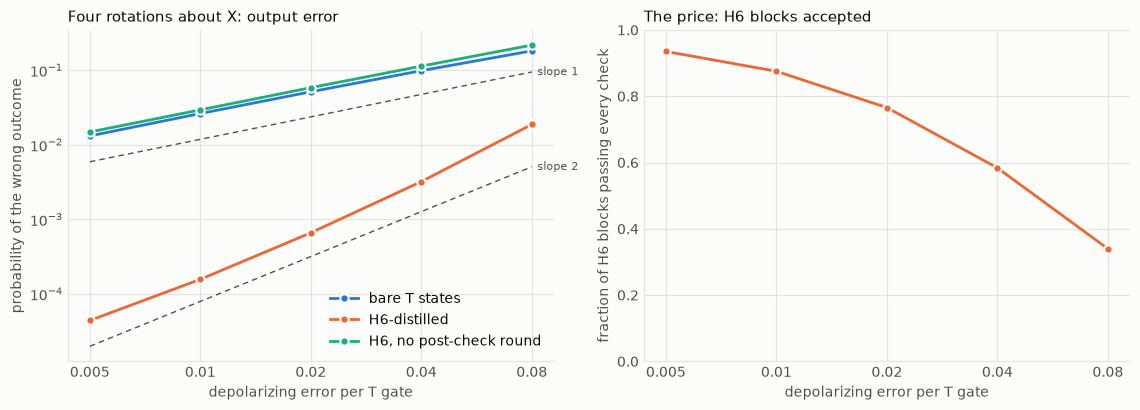

In [16]:
fig, (left, right) = new_axes(11.5, 4.2, ncols=2)
for (name, values), color in zip(errors.items(), (BLUE, ORANGE, AQUA)):
    line(left, P_T, values, color, name, yerr=sigmas[name])
guide(left, P_T, errors["bare T states"][0] * 0.45, 1, "slope 1")
guide(left, P_T, errors["H6-distilled"][0] * 0.45, 2, "slope 2")
left.set_xscale("log"); left.set_yscale("log")
left.set_xticks(P_T, [f"{p:g}" for p in P_T]); left.minorticks_off()
left.set_xlabel("depolarizing error per T gate", color=MUTED)
left.set_ylabel("probability of the wrong outcome", color=MUTED)
left.set_title("Four rotations about X: output error", color=INK, loc="left", fontsize=11)
left.legend(frameon=False, labelcolor=INK, loc="lower right")

line(right, P_T, block_accepted, ORANGE, None)
right.set_xscale("log"); right.set_ylim(0, 1)
right.set_xticks(P_T, [f"{p:g}" for p in P_T]); right.minorticks_off()
right.set_xlabel("depolarizing error per T gate", color=MUTED)
right.set_ylabel("fraction of H6 blocks passing every check", color=MUTED)
right.set_title("The price: H6 blocks accepted", color=INK, loc="left", fontsize=11)
fig.tight_layout()
plt.show()

- **Bare states:** the error is first order in $p_T$.
- **H6-distilled:** the error is second order. One fault is always detected; it takes two to get through. The gain over bare states grows as the T gates get better.
- **H6 without the post-check round:** first order again, and no better than bare. This is the X error that the proxy's readout cannot see.

The price is on the right: blocks that fail a check are thrown away.

### 7.2 The Fig. 4 circuit, with a known answer

The same measurement on the circuit from the slides. Run the Fig. 4 circuit and then its inverse: the ideal outcome is always `0000`. In Pauli product form the Cliffords cancel, leaving the four π/8 rotations of section 3 followed by their inverses, eight magic states in all, and Z measurements.

In [17]:
mirror = PPMProgram(N, program.rotations + [-p for p in reversed(program.rotations)],
                    [P("Z___"), P("_Z__"), P("__Z_"), P("___Z")])
print("ideal probability of 0000:", round(float(ppm_distribution(mirror)[0]), 6))

P_T_MIRROR = [0.005, 0.01, 0.02, 0.04]
MIRROR_SHOTS = 400_000  # per branch; there are 2**8 = 256 branches
mirror_errors = {"bare T states": [], "H6-distilled": []}
mirror_sigmas = {"bare T states": [], "H6-distilled": []}
for p in P_T_MIRROR:
    for name, make in (("bare T states", lambda: BareMagic(N, p_t=p)), ("H6-distilled", lambda: H6Magic(N, p_t=p))):
        rate, sigma = wrong(run(mirror, make, MIRROR_SHOTS), correct=0)
        mirror_errors[name].append(rate)
        mirror_sigmas[name].append(sigma)

mirror_gain = np.array(mirror_errors["bare T states"]) / np.array(mirror_errors["H6-distilled"])
print(f"\n{'p_T':>6}{'bare T states':>16}{'H6-distilled':>24}{'bare / H6':>12}")
for i, p in enumerate(P_T_MIRROR):
    h6_text = f"{mirror_errors['H6-distilled'][i]:.2e} +- {mirror_sigmas['H6-distilled'][i]:.0e}"
    print(f"{p:>6g}{mirror_errors['bare T states'][i]:>16.2e}{h6_text:>24}{mirror_gain[i]:>11.0f}x")
for name in mirror_errors:
    slope = np.polyfit(np.log(P_T_MIRROR), np.log(mirror_errors[name]), 1)[0]
    print(f"{name:>16}: error grows as p_T^{slope:.2f}")

ideal probability of 0000: 1.0



   p_T   bare T states            H6-distilled   bare / H6
 0.005        1.99e-02       2.28e-04 +- 3e-05         87x
  0.01        3.89e-02       9.48e-04 +- 6e-05         41x
  0.02        7.60e-02       3.65e-03 +- 2e-04         21x
  0.04        1.44e-01       1.57e-02 +- 6e-04          9x
   bare T states: error grows as p_T^0.95
    H6-distilled: error grows as p_T^2.03


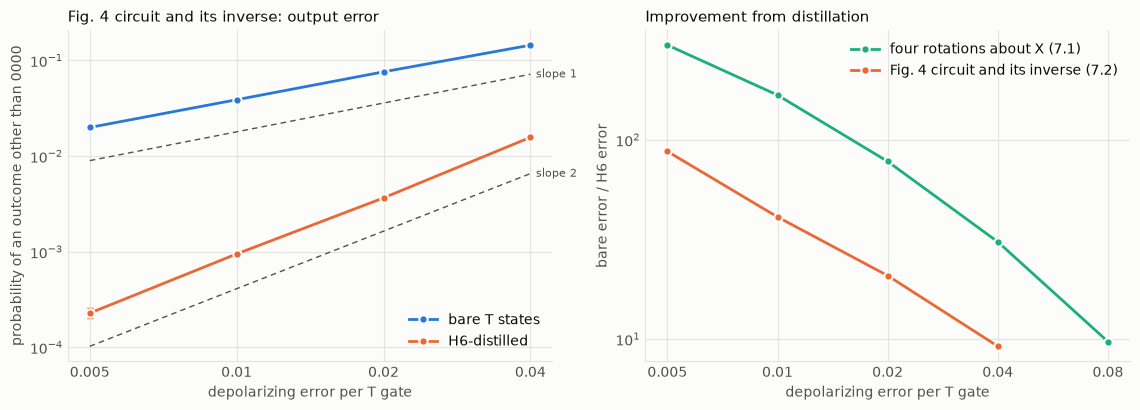

In [18]:
fig, (left, right) = new_axes(11.5, 4.2, ncols=2)
line(left, P_T_MIRROR, mirror_errors["bare T states"], BLUE, "bare T states", yerr=mirror_sigmas["bare T states"])
line(left, P_T_MIRROR, mirror_errors["H6-distilled"], ORANGE, "H6-distilled", yerr=mirror_sigmas["H6-distilled"])
guide(left, P_T_MIRROR, mirror_errors["bare T states"][0] * 0.45, 1, "slope 1")
guide(left, P_T_MIRROR, mirror_errors["H6-distilled"][0] * 0.45, 2, "slope 2")
left.set_xscale("log"); left.set_yscale("log")
left.set_xticks(P_T_MIRROR, [f"{p:g}" for p in P_T_MIRROR]); left.minorticks_off()
left.set_xlabel("depolarizing error per T gate", color=MUTED)
left.set_ylabel("probability of an outcome other than 0000", color=MUTED)
left.set_title("Fig. 4 circuit and its inverse: output error", color=INK, loc="left", fontsize=11)
left.legend(frameon=False, labelcolor=INK, loc="lower right")

line(right, P_T, gain, AQUA, "four rotations about X (7.1)")
line(right, P_T_MIRROR, mirror_gain, ORANGE, "Fig. 4 circuit and its inverse (7.2)")
right.set_xscale("log"); right.set_yscale("log")
right.set_xticks(P_T, [f"{p:g}" for p in P_T]); right.minorticks_off()
right.set_xlabel("depolarizing error per T gate", color=MUTED)
right.set_ylabel("bare error / H6 error", color=MUTED)
right.set_title("Improvement from distillation", color=INK, loc="left", fontsize=11)
right.legend(frameon=False, labelcolor=INK, loc="upper right")
fig.tight_layout()
plt.show()

The paper's circuit behaves like the one-qubit program: first order with bare states, second order with distilled ones, and a gain that grows as $p_T$ falls.

### 7.3 The Fig. 4 circuit itself

Last, the Fig. 4 program with its real, random output. The error is the total variation distance from the ideal distribution. A distance below the dashed line cannot be told apart from sampling noise.

   p_T      bare        H6   H6 runs accepted
  0.01    0.0047    0.0019              0.766
  0.02    0.0096    0.0025              0.586
  0.03    0.0146    0.0034              0.448
  0.05    0.0241    0.0051              0.261
  0.07    0.0341    0.0113              0.151
   0.1    0.0473    0.0215              0.068


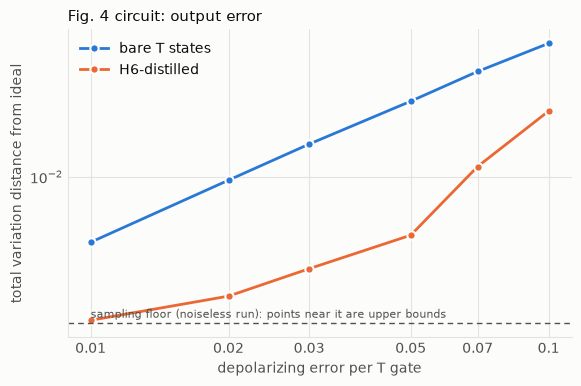

In [19]:
P_T4 = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1]
rows = []
for p in P_T4:
    bare = run(program, lambda: BareMagic(N, p_t=p), SHOTS)
    h6 = run(program, lambda: H6Magic(N, p_t=p), SHOTS)
    rows.append((total_variation(bare.distribution, ideal), total_variation(h6.distribution, ideal), h6.acceptance))
floor = total_variation(noiseless.distribution, ideal)

print(f"{'p_T':>6}{'bare':>10}{'H6':>10}{'H6 runs accepted':>19}")
for p, (b, h, a) in zip(P_T4, rows):
    print(f"{p:>6g}{b:>10.4f}{h:>10.4f}{a:>19.3f}")

fig, ax = new_axes(6.5, 4.0)
line(ax, P_T4, [r[0] for r in rows], BLUE, "bare T states")
line(ax, P_T4, [r[1] for r in rows], ORANGE, "H6-distilled")
ax.axhline(floor, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
ax.annotate("sampling floor (noiseless run): points near it are upper bounds", (P_T4[0], floor), xytext=(0, 4),
            textcoords="offset points", color=MUTED, fontsize=8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(P_T4, [f"{p:g}" for p in P_T4]); ax.minorticks_off()
ax.set_xlabel("depolarizing error per T gate", color=MUTED)
ax.set_ylabel("total variation distance from ideal", color=MUTED)
ax.set_title("Fig. 4 circuit: output error", color=INK, loc="left", fontsize=11)
ax.legend(frameon=False, labelcolor=INK, loc="upper left")
plt.show()

The distilled states give the lower error at every noise level. Below about $p_T = 0.03$ the H6 points sit on the sampling floor, so they are upper bounds and the true gain there is larger than the plot shows. Section 7.2 is the measurement of that gain.

### Summary

In [20]:
print("Stage 1: Clifford + T -> Pauli product measurements + magic states (exact)")
print(f"  Fig. 4 circuit              {len(circuit)} rotations ({len(cliffords)} Clifford, {len(program.rotations)} pi/8), {N} one-qubit measurements")
print(f"  compiled program            {len(program.rotations)} pi/8 rotations in {len(t_layers(program.rotations))} layer, {len(program.measurements)} Pauli product measurements, 0 Cliffords")
print(f"  executed schedule           {2 * len(program.rotations) + len(program.measurements)} measurements, {len(program.rotations)} magic states, no gates on the data")
print(f"  distance from the original  {total_variation(ideal, ppm_distribution(program)):.0e} (statevector);  "
      f"{total_variation(noiseless.distribution, ideal):.4f} (sampled, at the sampling floor)")

print("\nStage 2, factory only: bare vs H6-distilled magic states, noisy T gates")
print(f"{'':>8}{'four rotations about X':^34}{'Fig. 4 and its inverse':^34}{'cost of H6':^34}")
print(f"{'p_T':>8}{'bare':>11}{'H6':>11}{'gain':>10}  {'bare':>11}{'H6':>11}{'gain':>10}  {'blocks accepted':>17}{'T gates per state':>19}")
for i, p in enumerate(P_T):
    row = f"{p:>8g}{errors['bare T states'][i]:>11.1e}{errors['H6-distilled'][i]:>11.1e}{gain[i]:>9.0f}x  "
    if p in P_T_MIRROR:
        j = P_T_MIRROR.index(p)
        row += f"{mirror_errors['bare T states'][j]:>11.1e}{mirror_errors['H6-distilled'][j]:>11.1e}{mirror_gain[j]:>9.0f}x  "
    else:
        row += f"{'-':>11}{'-':>11}{'-':>10}  "
    print(row + f"{block_accepted[i]:>17.3f}{7 / block_accepted[i]:>19.1f}")
print("\nT gates per state: 14 per block, 2 states per block, divided by the fraction of blocks accepted. A bare state costs 1.")

Stage 1: Clifford + T -> Pauli product measurements + magic states (exact)
  Fig. 4 circuit              21 rotations (17 Clifford, 4 pi/8), 4 one-qubit measurements
  compiled program            4 pi/8 rotations in 1 layer, 4 Pauli product measurements, 0 Cliffords
  executed schedule           12 measurements, 4 magic states, no gates on the data
  distance from the original  2e-16 (statevector);  0.0018 (sampled, at the sampling floor)

Stage 2, factory only: bare vs H6-distilled magic states, noisy T gates
              four rotations about X            Fig. 4 and its inverse                  cost of H6            
     p_T       bare         H6      gain         bare         H6      gain    blocks accepted  T gates per state
   0.005    1.3e-02    4.4e-05      299x      2.0e-02    2.3e-04       87x              0.935                7.5
    0.01    2.6e-02    1.6e-04      168x      3.9e-02    9.5e-04       41x              0.875                8.0
    0.02    5.1e-02    6.6e-04    

## What this simulation leaves out

- **The compute block is not on code patches (slides 9 to 11).** The four data qubits are ideal, noiseless qubits, not surface code patches, and each joint measurement $P \otimes Y_L$ is one noiseless `MPP`, not a lattice-surgery measurement through an ancilla patch as in Fig. 8. The demo uses only LightStim imports, and LightStim's rotated-surface-code Pauli product measurement takes X and Z terms only. The Fig. 4 program needs Y terms (`YZZY`, `_XY_`, and $Y_L$ on the factory side).
- **So only the factory is simulated at the physical level.** The results in section 7 are about magic state quality, not about the logical error of the compute block or the space-time cost of the layout.
- **Only T gates are noisy here.** `H6Magic(..., p=...)` adds LightStim's circuit-level noise to the Clifford operations of the block. An X error after the last SE round is then not caught, so the suppression is no longer second order.
- **Two input errors pass the check.** The check accepts $|H-,H-\rangle$. The paper's randomized twirl addresses this and is not implemented.
- **LightStim version.** The H6 protocol comes from `maggie-bao202/LightStim@feat/h6-distillation-protocol` (open PR #108). It is not on `QuTone/LightStim` main yet.